In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload
import os, sys, ast
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
rcParams['font.size'] = 10

In [2]:
#load atlas
template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"
template = tifffile.imread(template_path)

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\4158968567.py:2: SyntaxWarning: invalid escape sequence '\D'
  template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"


In [50]:
def plot_timing(stim_responses):
    region_list = ['pretectum', 'tectum', 'rhombencephalon_(hindbrain)']
    #region_list = ['i']
    fig = plt.figure(dpi=240, figsize=(15,10))
    gs = gridspec.GridSpec(len(region_list), 4, figure=fig)
    ax_imshow_all = fig.add_subplot(gs[:, 0])

    #only plot visually responsive neurons that have been somewhat barrcoded
    barred = set(stim_responses.index[(stim_responses.filter(like="barred_").any(axis=1))])
    barred_hist = set(stim_responses.index[(stim_responses.filter(like="barred_").any(axis=1))])

    for i, r in enumerate(region_list):
        if type(r) == list:
            region_n = set(stim_responses.index[stim_responses['regions'].apply(lambda x: any(ri in x for ri in r))])
        else:
            region_n = set(stim_responses.index[stim_responses['regions'].apply(lambda x: r in x)])#set(stim_responses.index)
        barred_r = list(region_n & barred)
        barred_hist_r = list(region_n & barred_hist)

        #manage figure space
        ax_timing_all = fig.add_subplot(gs[i, 1])
        ax_timing_all.set_ylim([0, 1])
        ax_timing_all.set_xlim([-1, 1])
        ax_heat = fig.add_subplot(gs[i, 2])
        ax_hist = fig.add_subplot(gs[i, 3])
        #
        #color: tuned angles
        colors = stim_responses.loc[barred_r, 'timing']
        colors = plt.cm.plasma(plt.Normalize(vmin=-.2, vmax=.2)(colors))
        #alpha: dsi
        alphas = stim_responses.loc[barred_r, 'DSI']
        alphas = [i if not np.isnan(i) else 0 for i in alphas]
        #ax_imshow_all.scatter(stim_responses.loc[barred_r, 'xpos'], stim_responses.loc[barred_r, 'ypos'], c = colors, s = 1, alpha = .5, marker = '.')

        #plot vector plot
        selected_responses = stim_responses.loc[barred_r]
        times = selected_responses.loc[:, 'timing'].values
        mags = selected_responses.loc[:, 'DSI'].values
        #ax_timing_all.scatter(times, mags, c=colors, alpha=0.7, s=.1)
        ax_timing_all.set_axis_off()
        #plot it across all neurons
        #ax_imshow_all.imshow(template[220], cmap = 'gray', vmax = 400)
        ax_imshow_all.set_axis_off()

        #plot heatmap
        timing_bins = np.linspace(-1, 1, 73)
        r_bins = np.linspace(0, 1, 40)
        Hs = []
        for f in selected_responses.real_fish_id.unique():
            f_response = selected_responses.loc[selected_responses.real_fish_id == f]
            times = f_response.loc[:, 'timing'].values
            mags = f_response.loc[:, 'DSI'].values
            H, timing_edges, r_edges = np.histogram2d(times, mags, bins=[timing_bins, r_bins])
            H = H / H.sum() * 100
            Hs.append(H)
        H = np.mean(np.array(Hs), axis = 0)
        T, R = np.meshgrid(timing_edges, r_edges)
        #ax_heat.pcolormesh(T, R, H.T, vmin = 0, vmax = 1)
        ax_heat.set_aspect('equal')
        ax_heat.set_axis_off()
        #
        #plot histogram
        hist_data = stim_responses.loc[barred_hist_r]
        # bin DSI2 into 0.1 steps
        bins = np.arange(-1, 1.1, 0.025)
        hist_data['timing'] = pd.to_numeric(hist_data['timing'], errors='coerce')
        hist_data = hist_data.dropna(subset=['timing'])
        hist_data['timing_bin'] = pd.cut(hist_data['timing'], bins=bins, include_lowest=True)
        hist_data['timing_bin'] = hist_data['timing_bin'].apply(lambda x: x.left + (x.right - x.left)/2)
        # compute mean probability per bin for each fish
        bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
        bin_stats['prob'] = bin_stats.groupby('real_fish_id')['count'].transform(lambda x: x / x.sum())
        # plot mean across fish with confidence interval
        sns.lineplot(data=bin_stats,x='timing_bin',y= 'prob', errorbar='se',ax=ax_hist)
        ax_hist.axvline(np.nanmean(hist_data['timing']), linewidth = 1, linestyle = ":")
        print(np.nanmean(hist_data['timing']))
        ax_hist.set_ylim([0, .2])
        ax_hist.set_ylabel('')
        ax_hist.spines[['top', 'right']].set_visible(False)
    return fig

C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

-0.0171598857525572
-0.014152971538311692
-0.010815932133385027


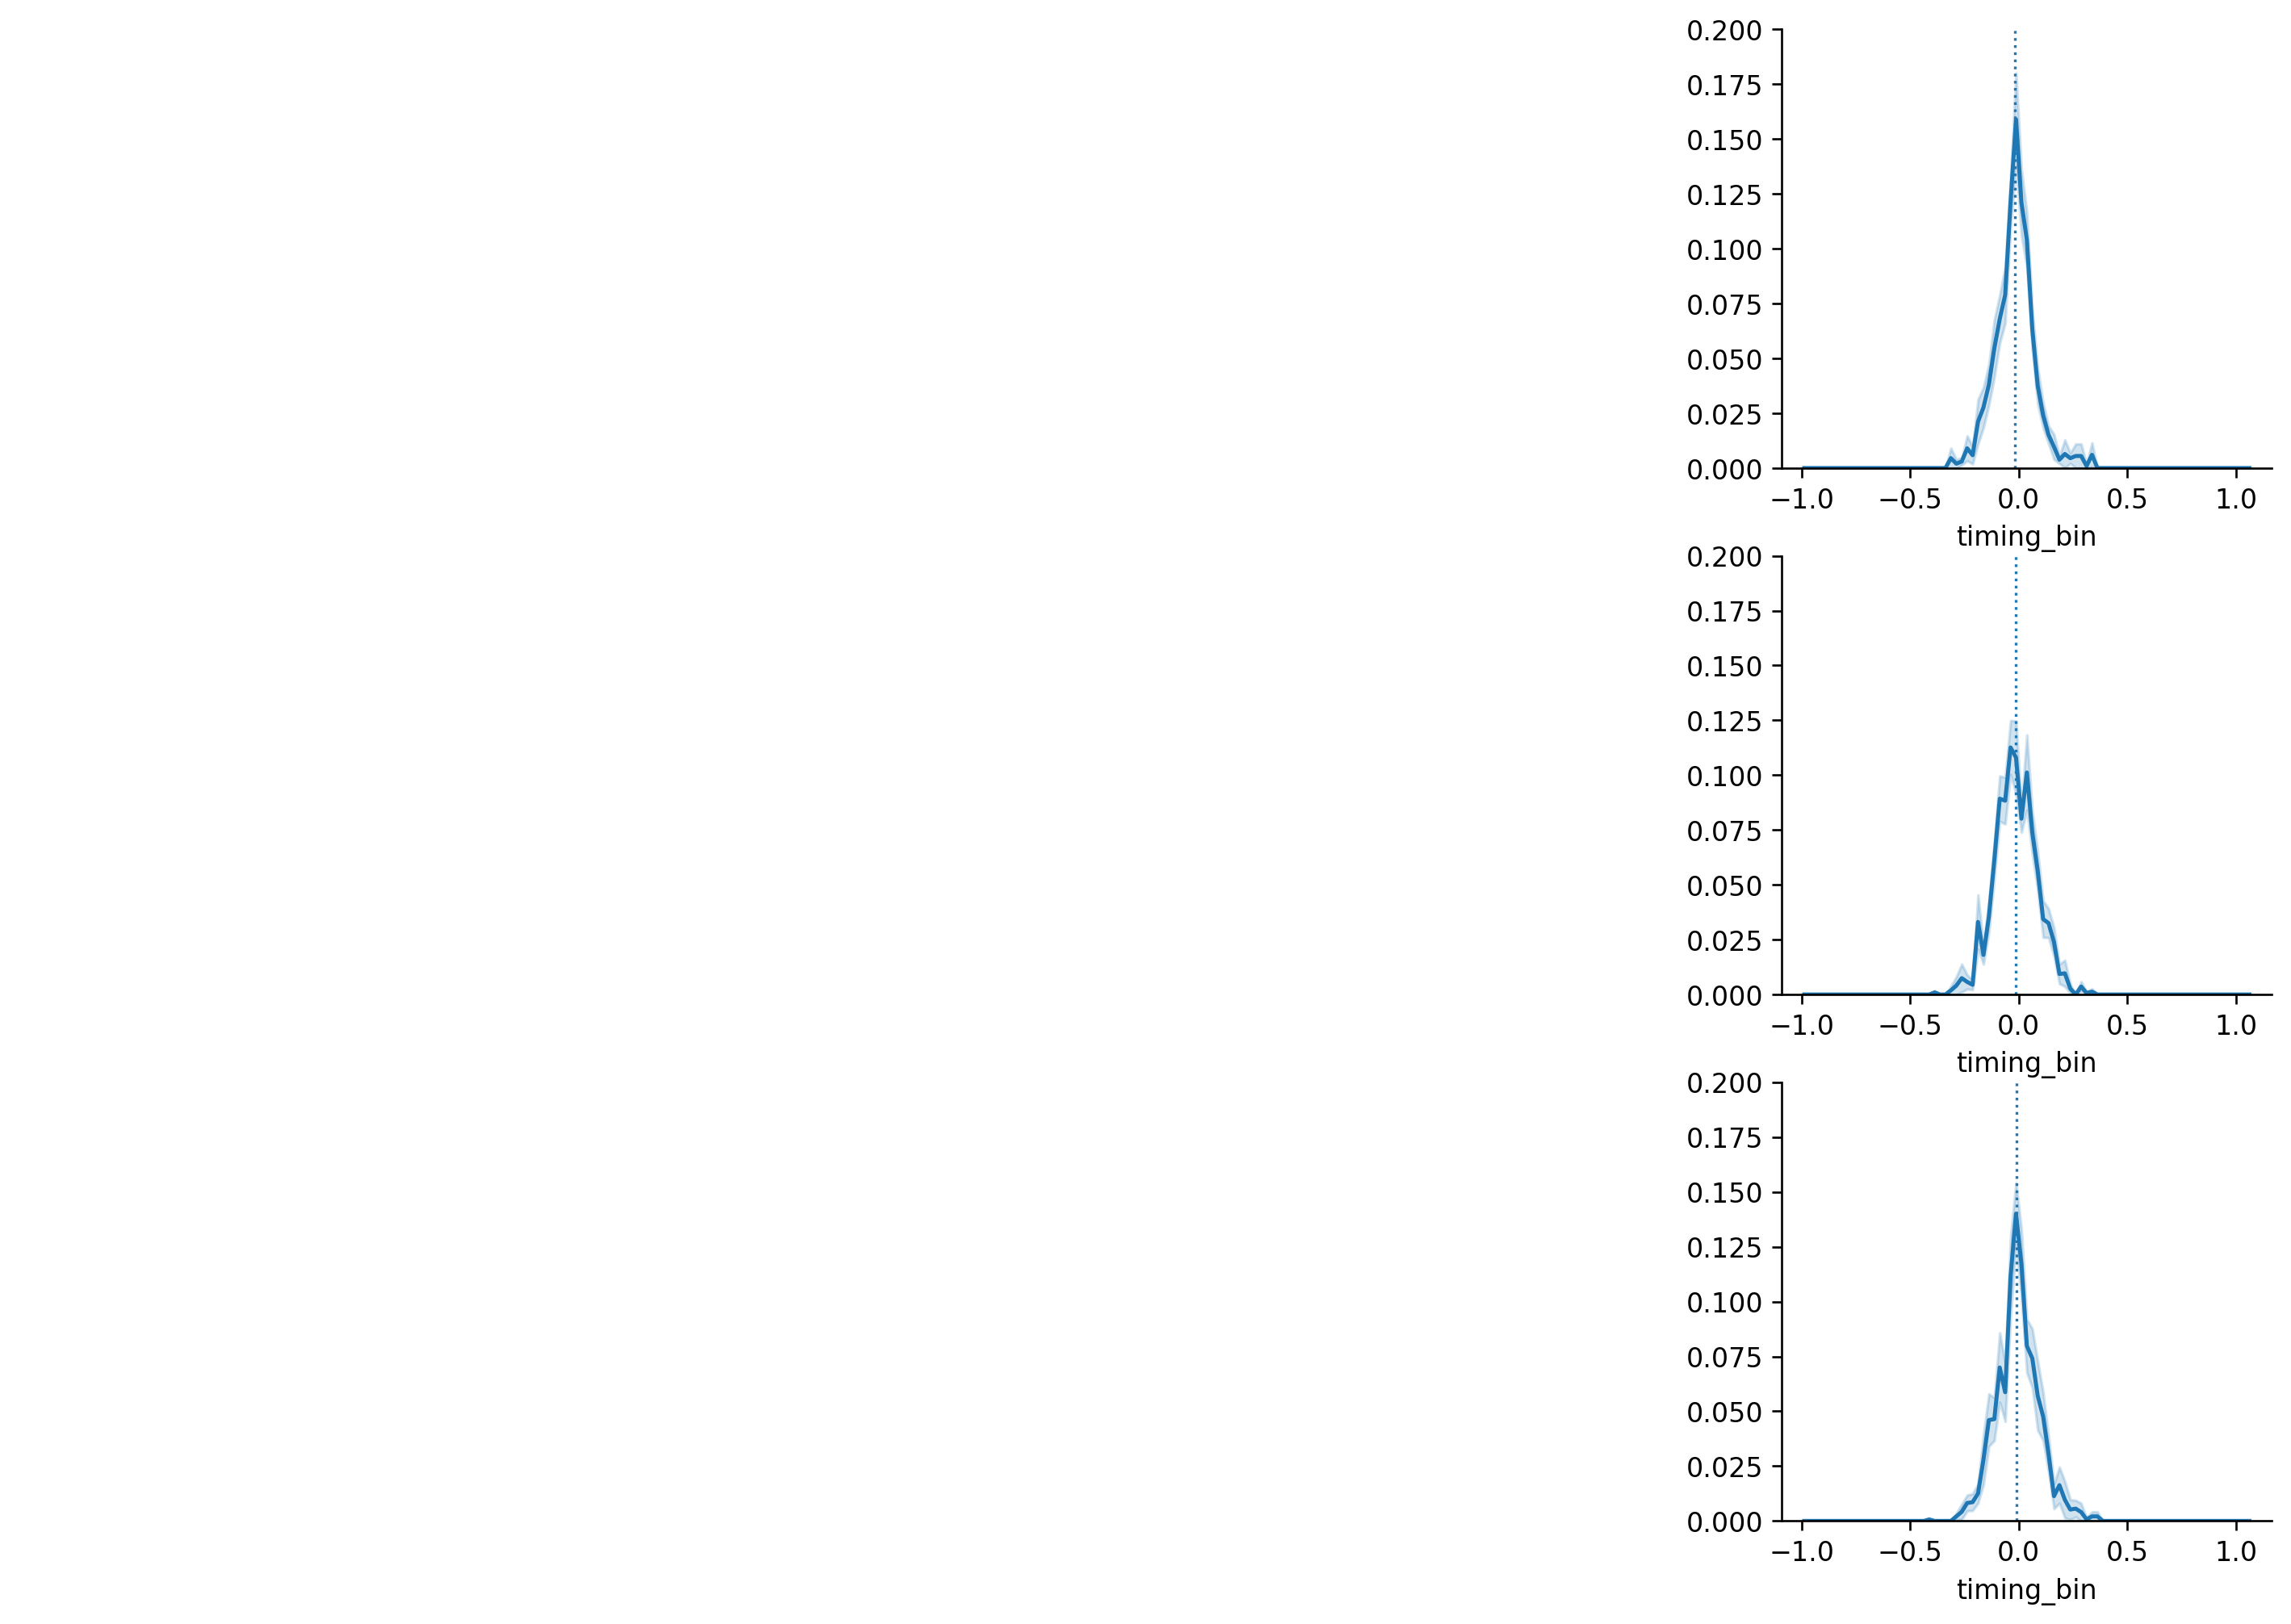

In [51]:
paths =[
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]

grating_responses = []
for path in paths:
    grating_response = pd.read_csv(path + '//analyze_results//dot_responses.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos_all.csv', index_col = 0, converters={"regions": lambda x: [] if (pd.isna(x) or str(x)=="[]" or str(x) == "") else ast.literal_eval(x)})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        #neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
    grating_response.loc[:, 'fish_id'] = path
    grating_response.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]
    grating_responses.append(grating_response)
grating_responses = pd.concat(grating_responses).reset_index()
fig = plot_timing(grating_responses)
plt.savefig(r"C:\Data\Imaging\260425_overlap\All_imaging//dottiming.svg")
plt.show()
plt.close()

C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')


0.005082120621788245
0.011208354263370053
-0.009572226560966585


C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')


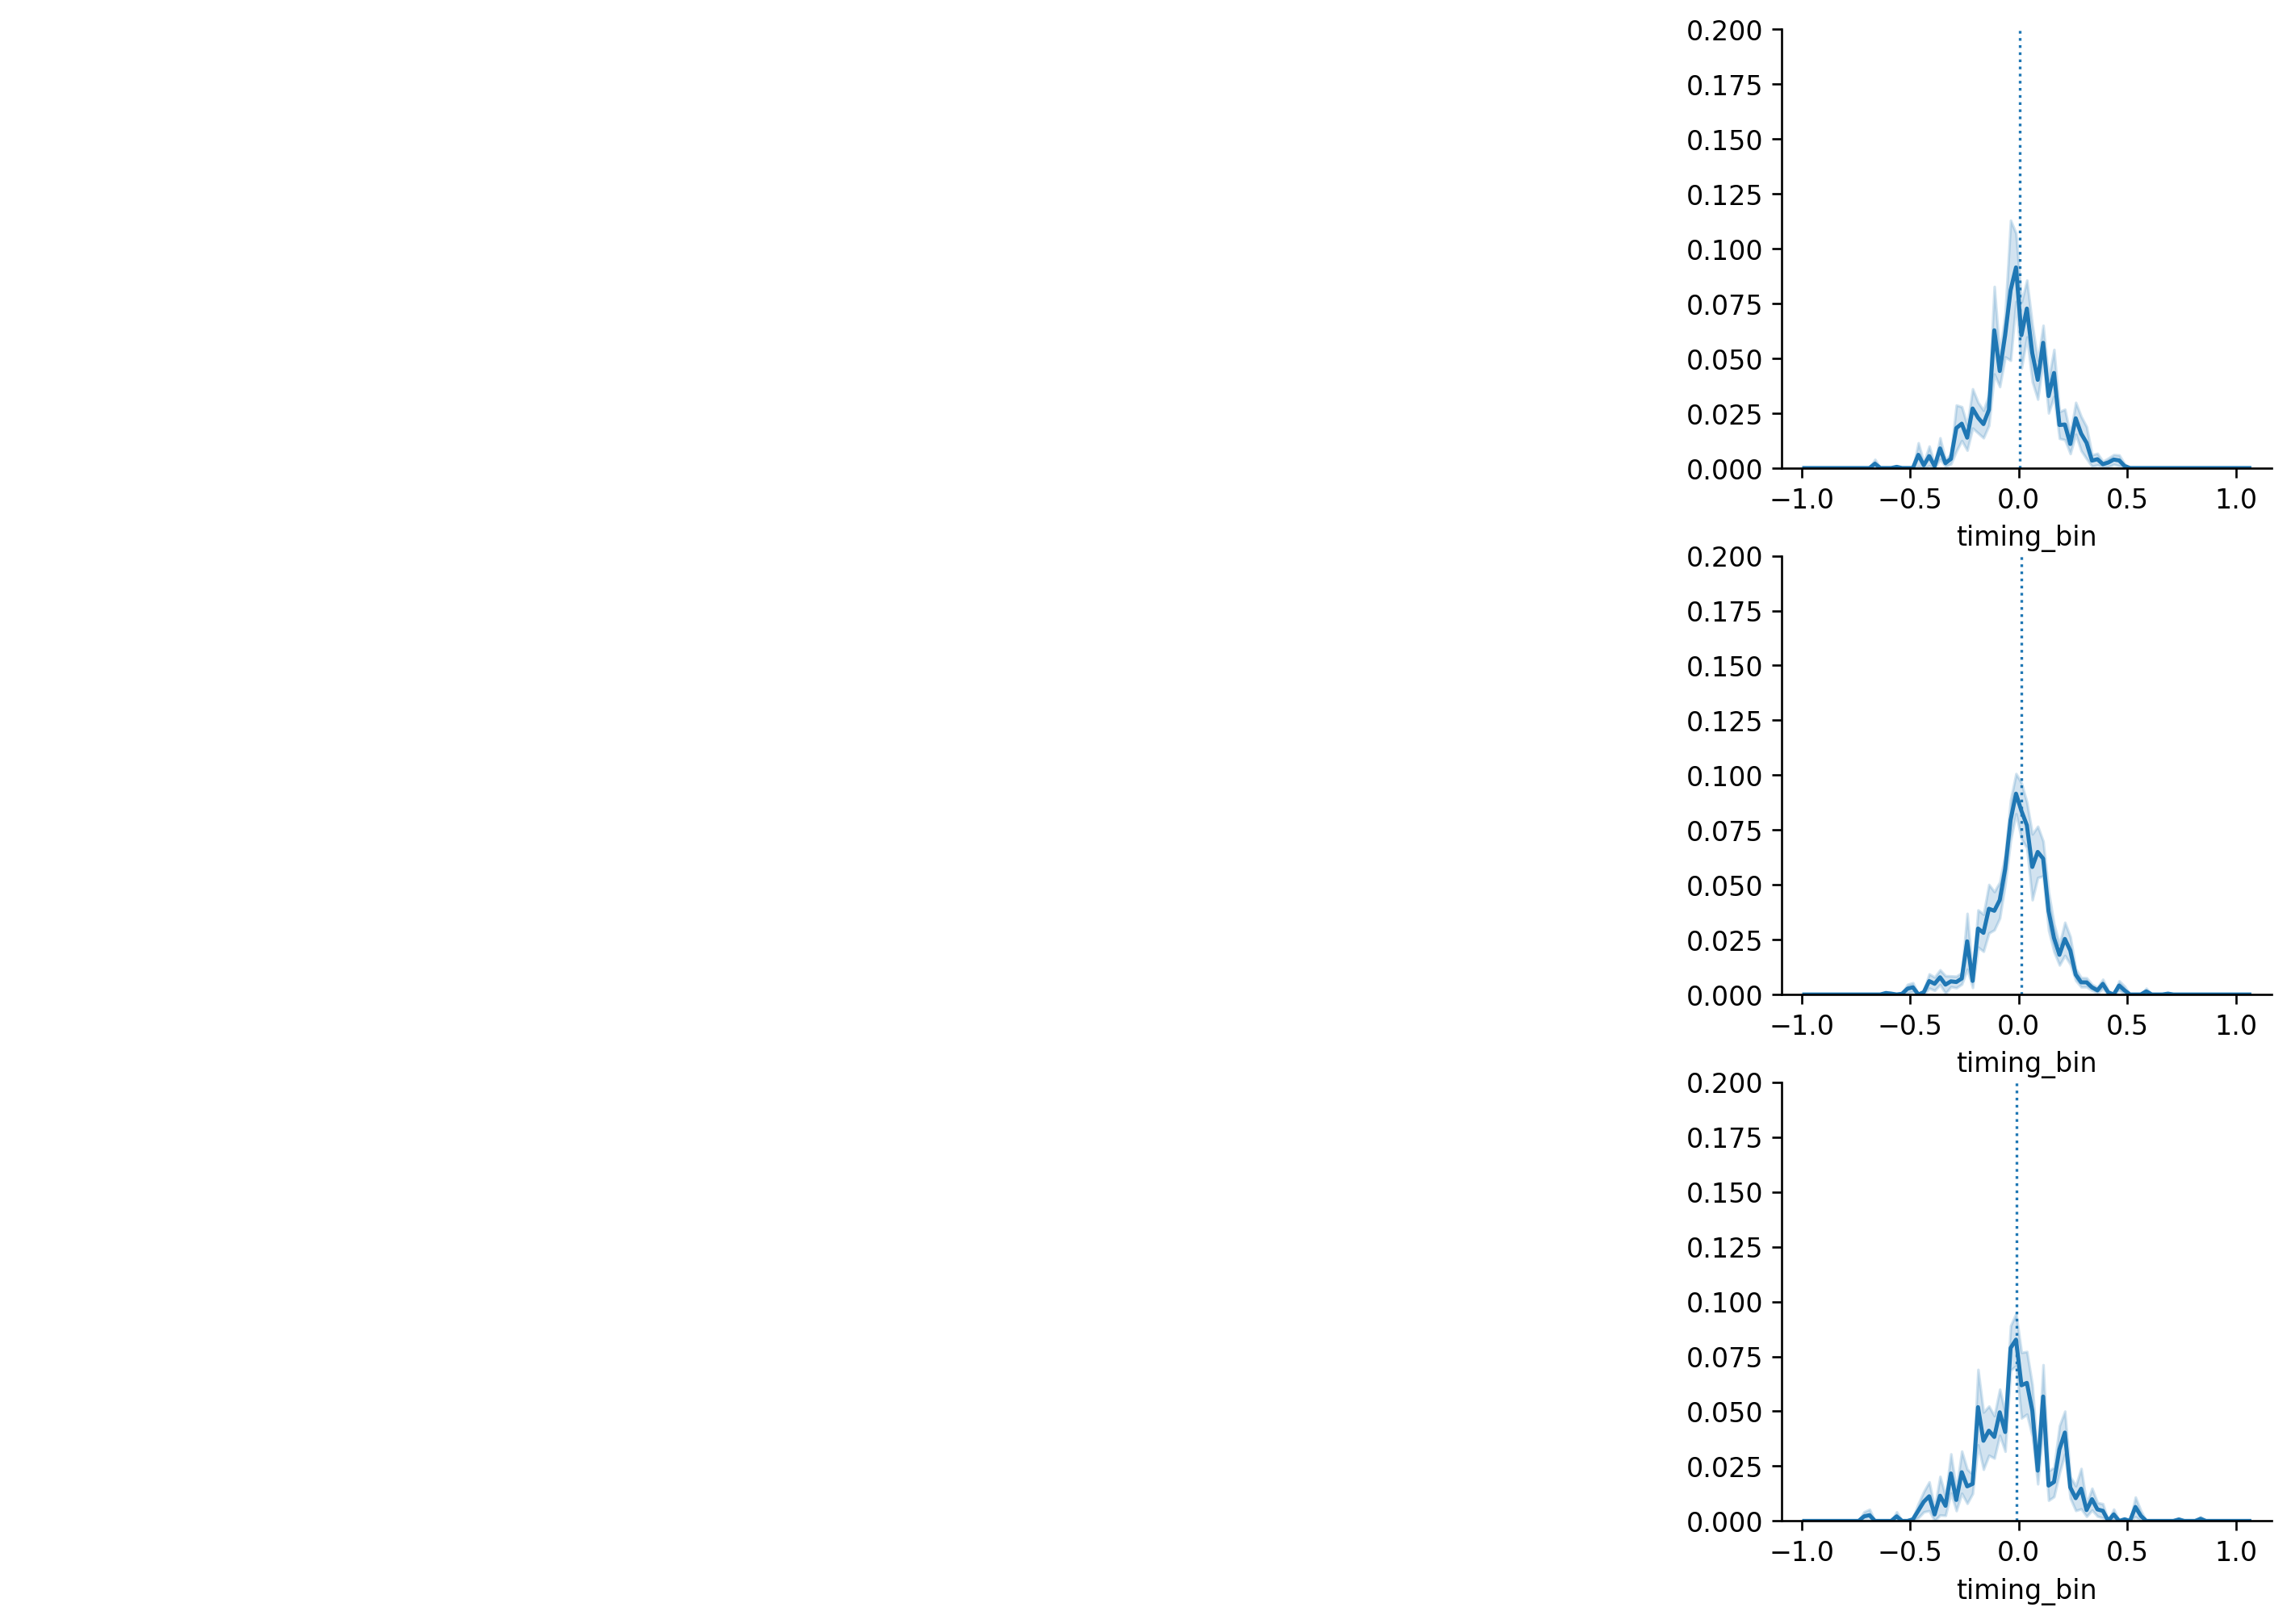

C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

-0.009541241091863646
-0.0012327471084432478
-0.020448479131748402


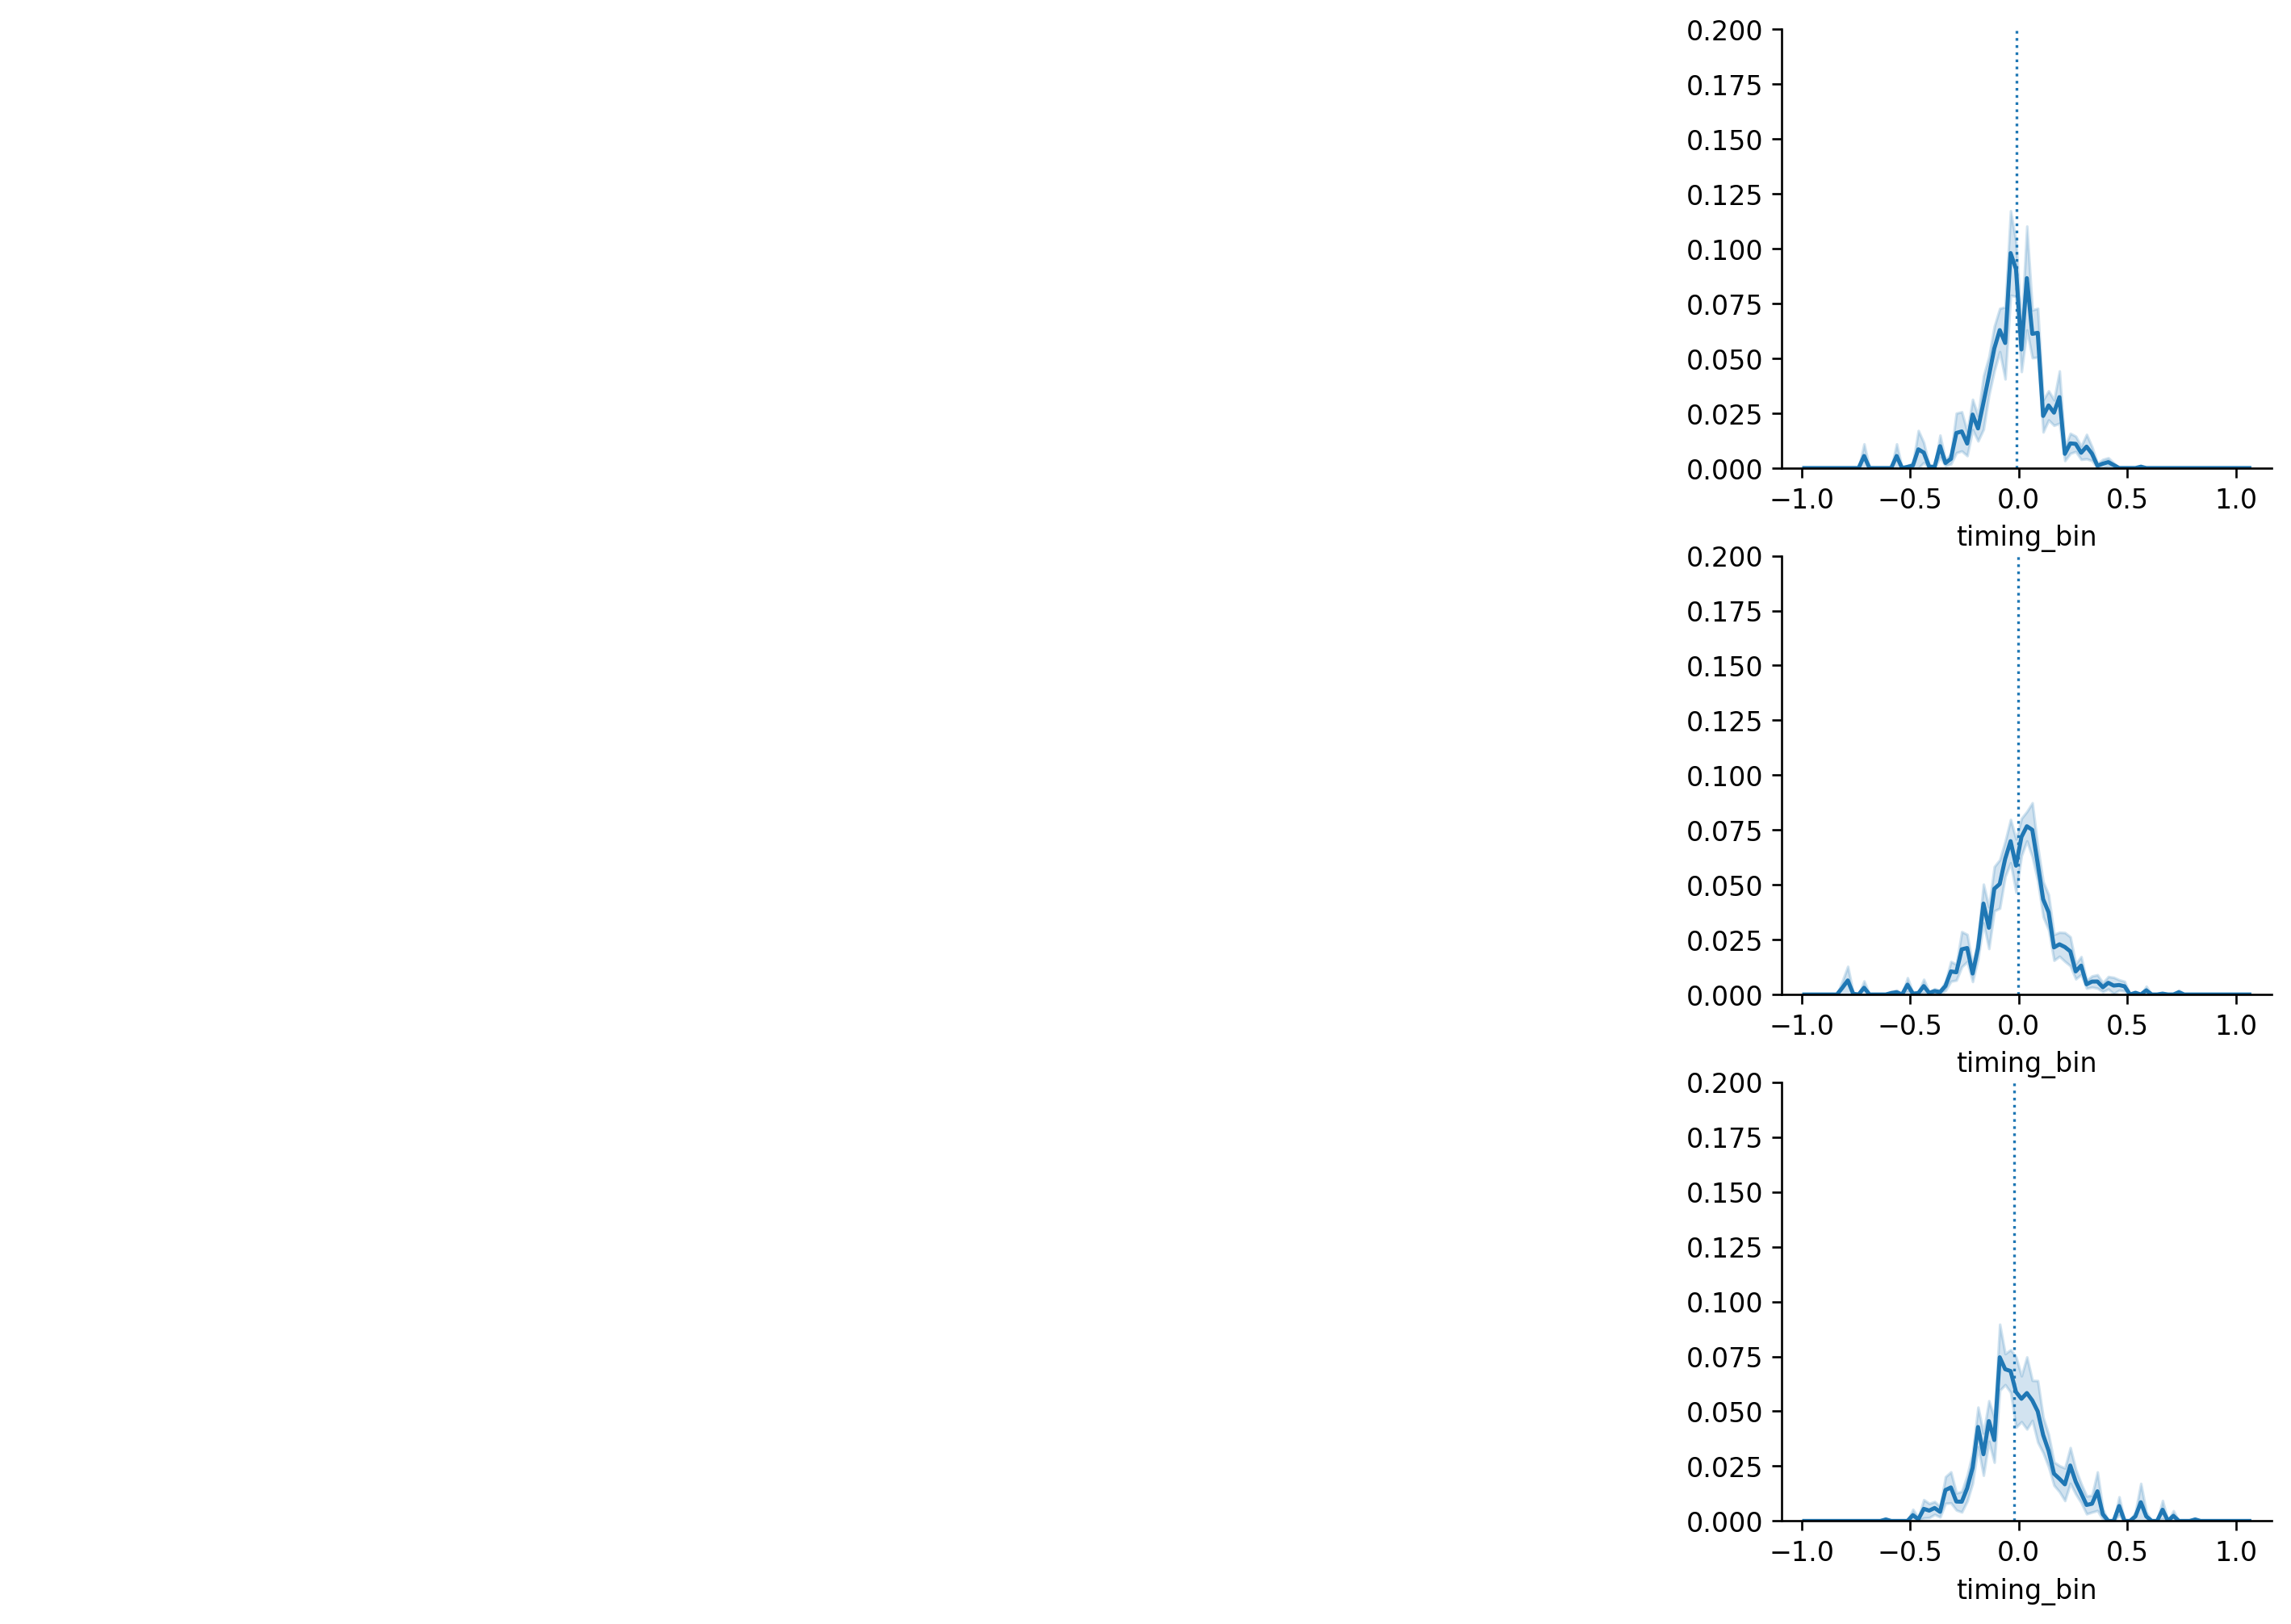

C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

-0.00534575688979792
-0.004656412382601889
0.008610249280444656


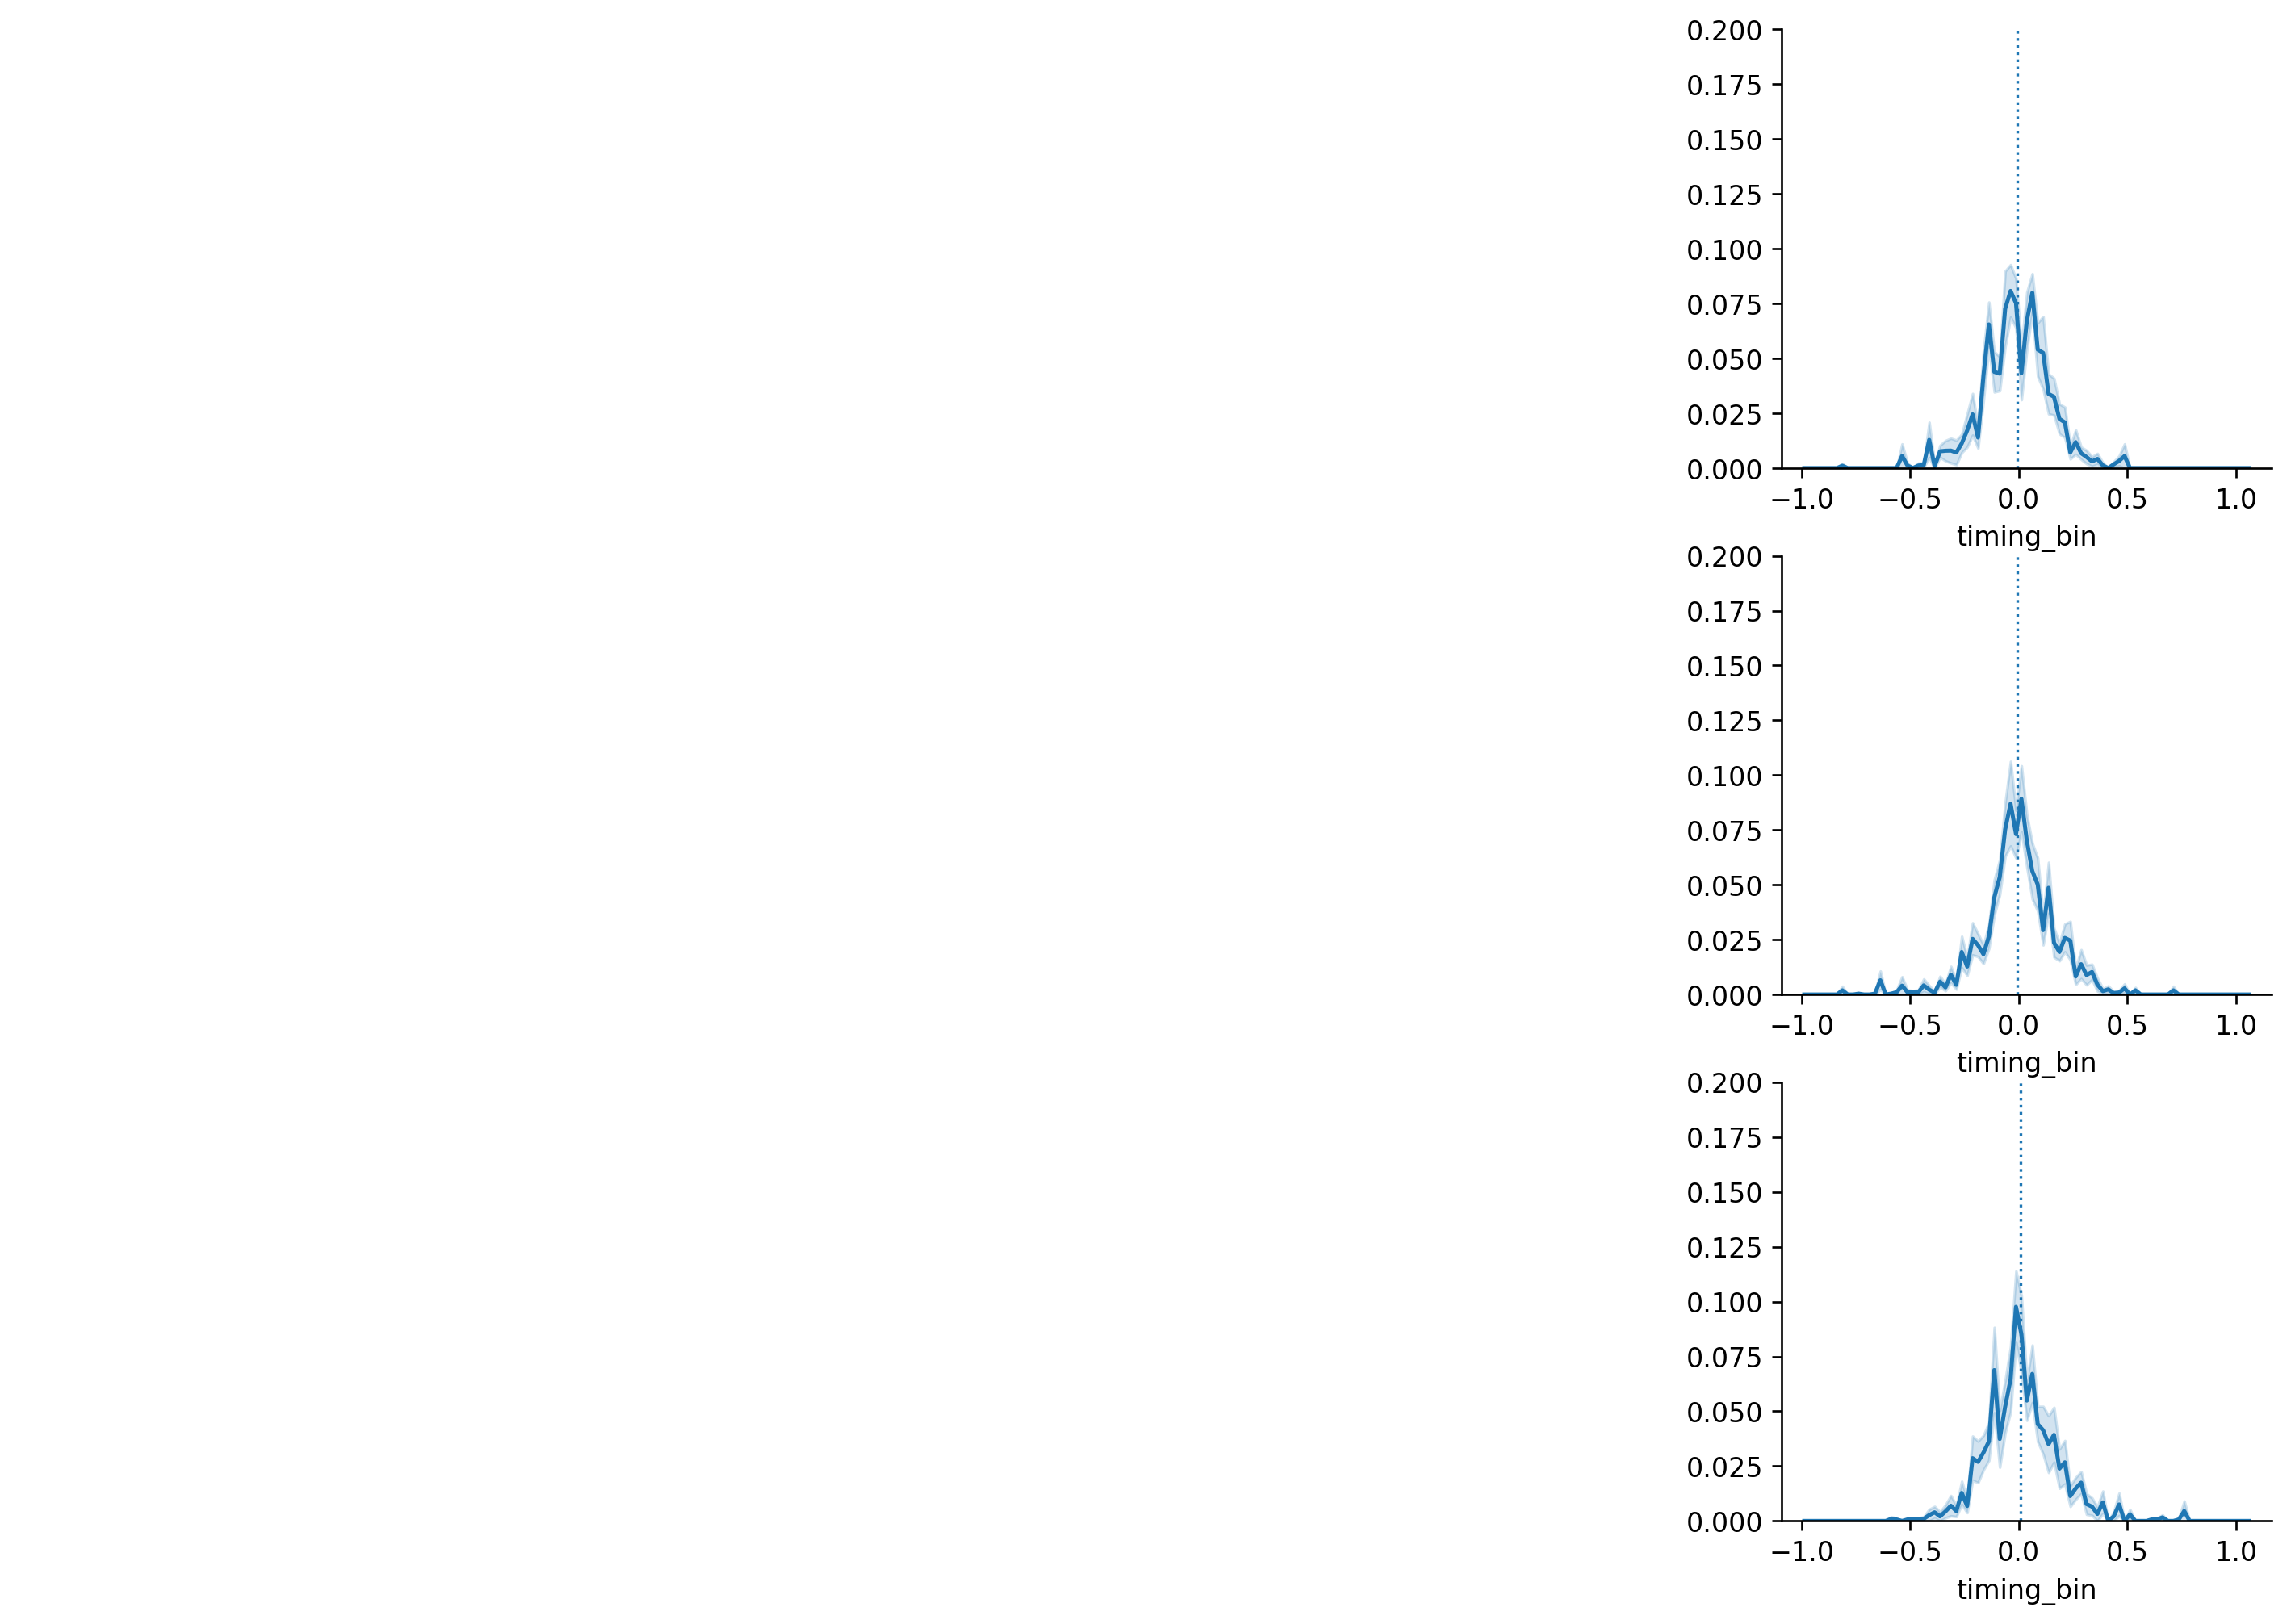

C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['timing_bin', 'real_fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_33948\939794510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

0.011666195849983465
0.012394674886863716
0.009566650693082606


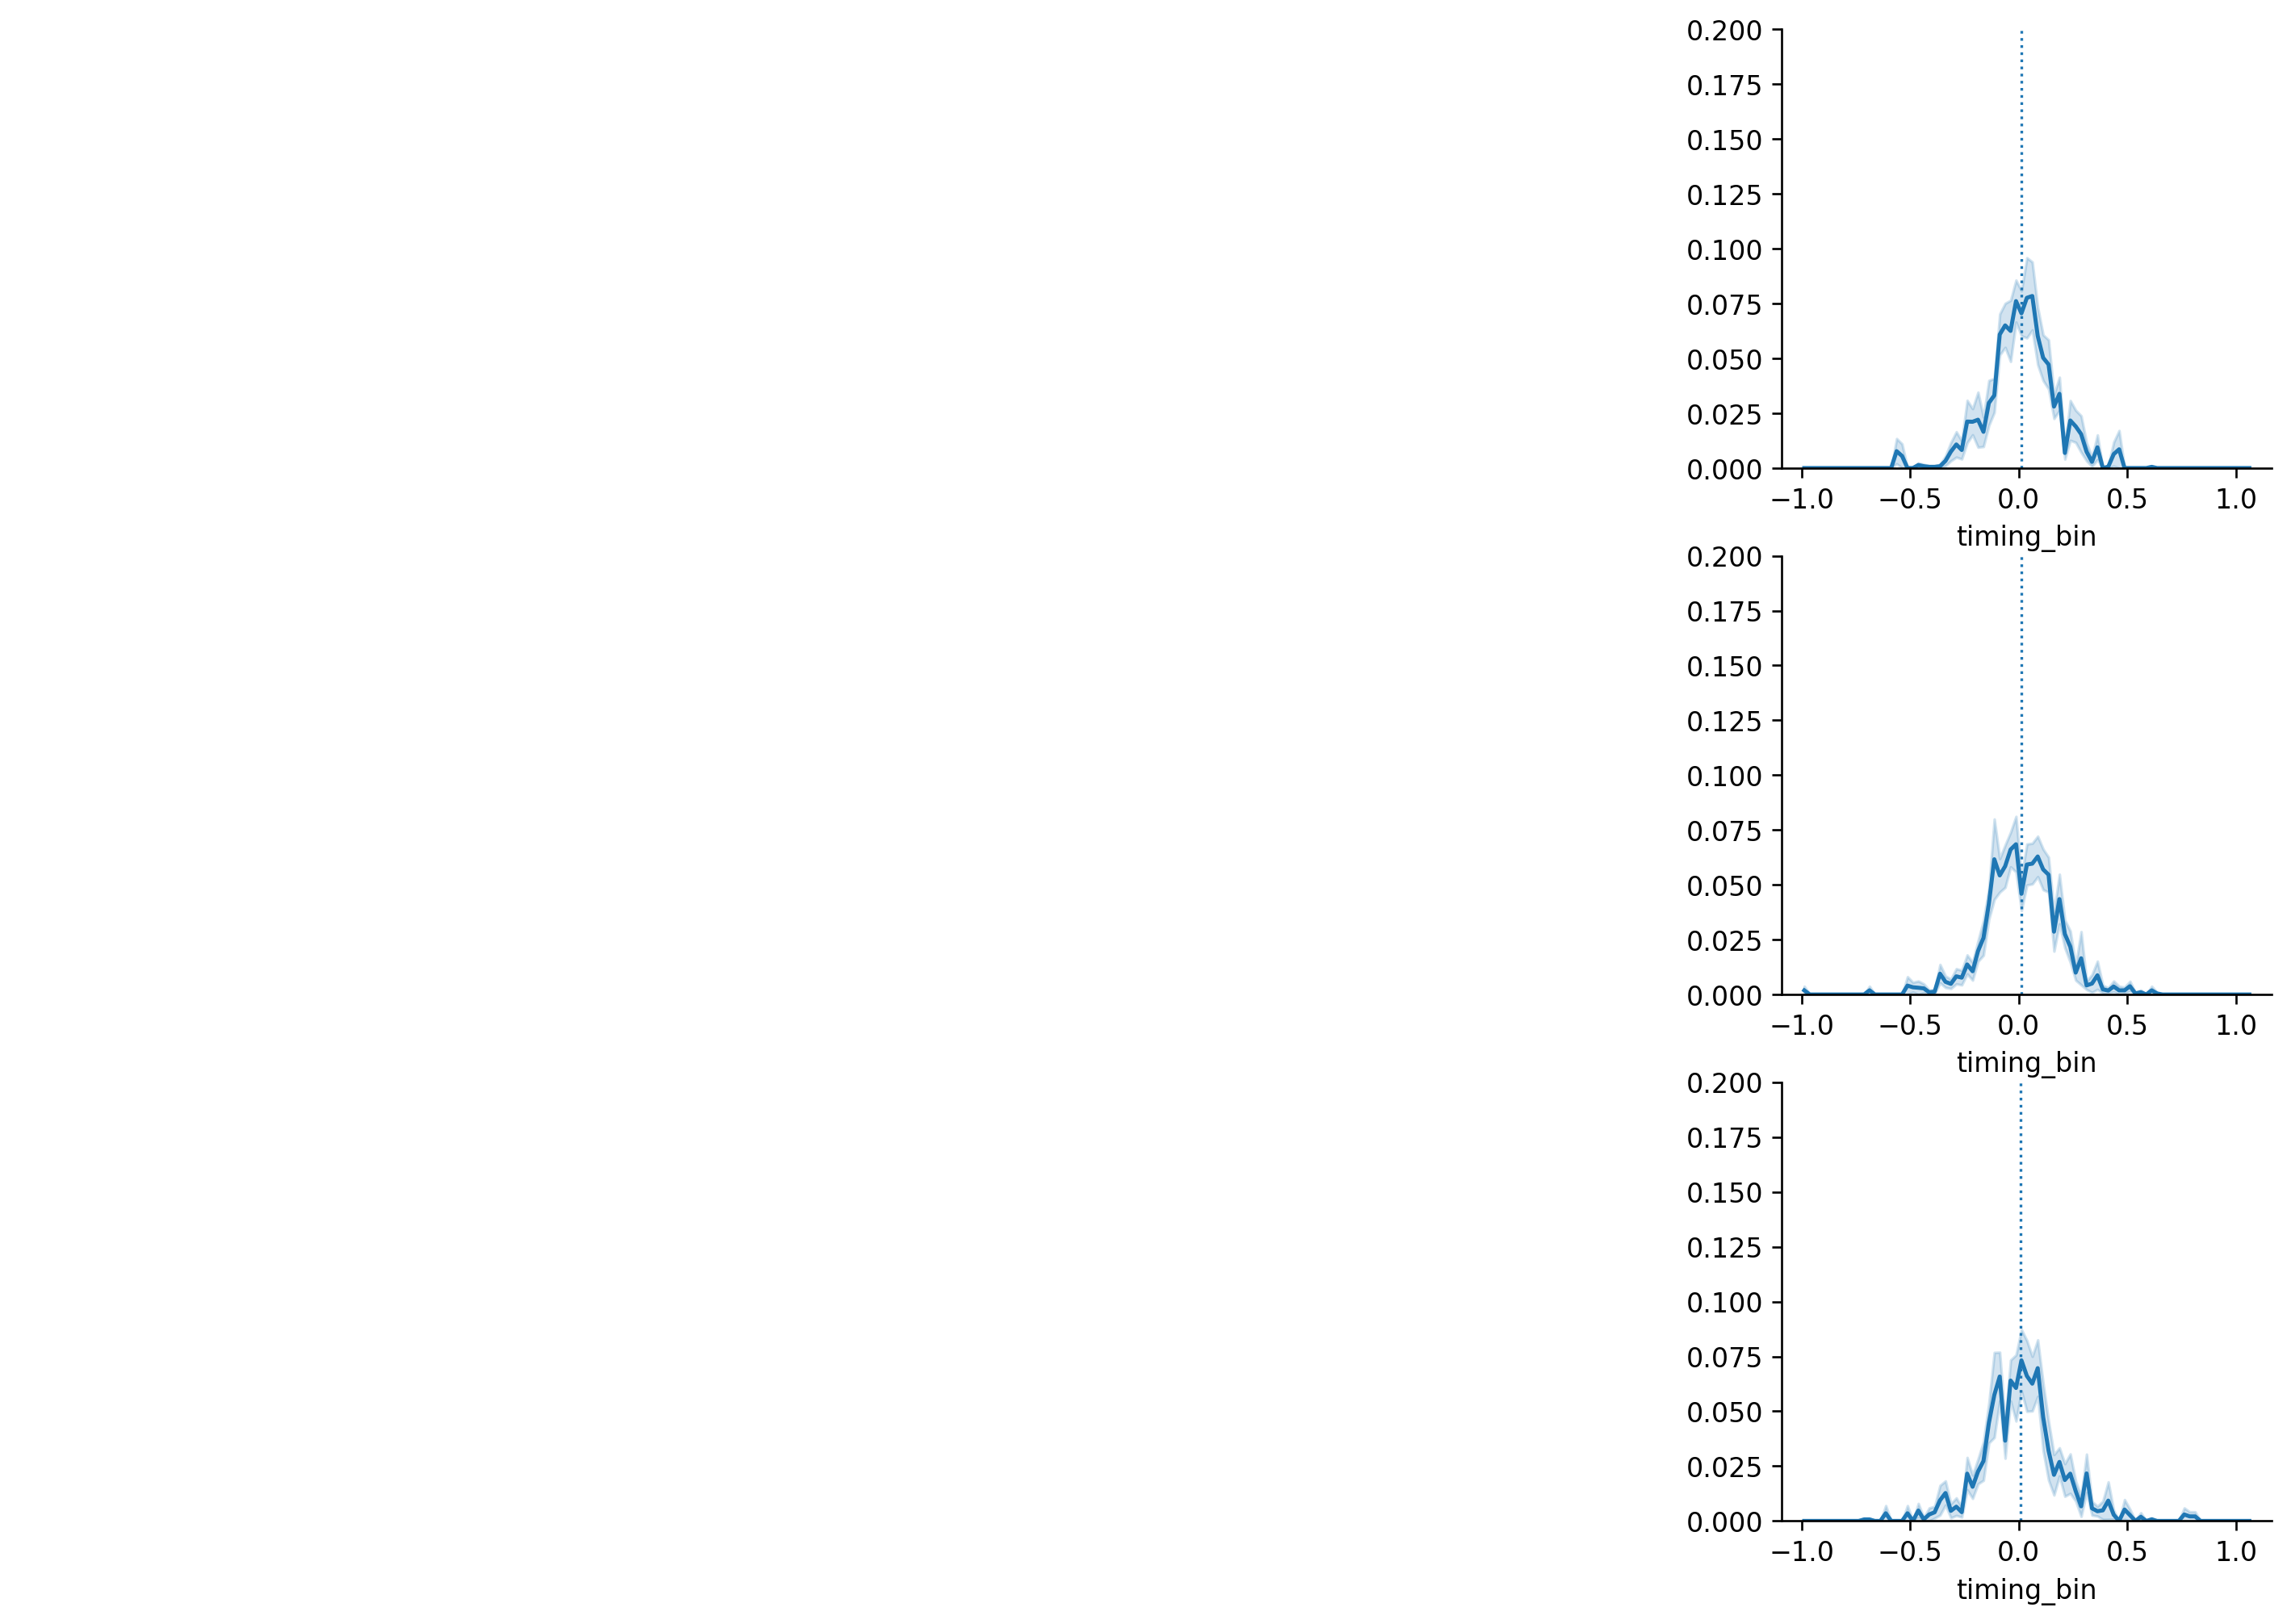

In [52]:
for grating in ['forward', 'left', 'right', 'backward']:
    grating_responses = []
    for path in paths:
        grating_response = pd.read_csv(path + f'//analyze_results//dot_responses_[{grating}].csv', index_col = 0)
        new_poses = []
        neuron_count = 0
        for plane in range(5):
            new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos_all.csv', index_col = 0, converters={"regions": lambda x: [] if (pd.isna(x) or str(x)=="[]" or str(x) == "") else ast.literal_eval(x)})
            # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
            # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
            # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
            # avg_zpos = np.array([plane] * len(avg_xpos))
            # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
            #                                    columns = ['xpos', 'ypos', 'zpos'],
            #                                    index = np.add(range(len(avg_xpos)), neuron_count))
            #neuron_count += len(avg_xpos)
            new_poses.append(new_pos)
        new_poses = pd.concat(new_poses, ignore_index = True)
        grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
        grating_response.loc[:, 'fish_id'] = path
        grating_response.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]
        grating_responses.append(grating_response)
    grating_responses = pd.concat(grating_responses).reset_index()
    fig = plot_timing(grating_responses)
    plt.savefig(rf"C:\Data\Imaging\260425_overlap\All_imaging//dottiming_[{grating}].svg")
    plt.show()
    plt.close()